# 1번 (1-1)

### 평균 배송일이 늦었음에도 불구하고 평균 리뷰가 좋은 주들이 존재함.

가설1: 이유는 카테고리 때문일 것이다.

가설2: 이유는 배송 거리가 멀었을 것이다.

가설3: 가격이 높은 제품이었을 것이다.

가설4: 배송비가 높은 제품이었을 것이다.


## 타겟 state: AM, AP

### 머신러닝 활용법: 

리뷰평점 vs 배송일, 배송거리, 가격, 배송비, 배송비비중, product_category

모델을 만들고나서 feature importance를 보게되면 위 통계분석에서 발견한 패턴을 검증

특히나 설명력 높은 변수 찾아보기

모델로 도출가능한 인사이트: 고객 리뷰를 높이고 싶다면, 배송일, 배송거리, 가격, 배송비 중에서 무엇에 집중하면 된다.

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import category_encoders as ce
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import spearmanr
import shap
from xgboost import XGBRegressor, DMatrix
from haversine import haversine_vector, Unit

# 1단계) 필수전처리 

테이블병합 - 카테고리영문조인 - 배송완료건 필터 - 배송시간,배송비비율,거리 파생변수 설정 - 필수변수 null 제거

In [2]:
# 1. 테이블 load

# Orders
df_orders = pd.read_csv("data/olist_orders_dataset.csv")

# Order Items
df_order_items = pd.read_csv("data/olist_order_items_dataset.csv")

# Order Reviews
df_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

# Products
df_products = pd.read_csv("data/olist_products_dataset.csv")

# Sellers
df_sellers = pd.read_csv("data/olist_sellers_dataset.csv")

# Customers
df_customers = pd.read_csv("data/olist_customers_dataset.csv")

# Geolocation
df_geo = pd.read_csv("data/olist_geolocation_dataset.csv")

# Product Category Translation
df_category_translation = pd.read_csv("data/product_category_name_translation.csv")

# Order Payments
df_payments = pd.read_csv("data/olist_order_payments_dataset.csv")

# 날짜형 변환
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in order_date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

review_date_cols = ["review_creation_date", "review_answer_timestamp"]
for col in review_date_cols:
    if col in df_reviews.columns:
        df_reviews[col] = pd.to_datetime(df_reviews[col], errors="coerce")

In [3]:
# 2. 거리 정보 처리

# ZIP prefix 타입 통일
df_geo["geolocation_zip_code_prefix"] = df_geo["geolocation_zip_code_prefix"].astype(int)
df_customers["customer_zip_code_prefix"] = df_customers["customer_zip_code_prefix"].astype(int)
df_sellers["seller_zip_code_prefix"] = df_sellers["seller_zip_code_prefix"].astype(int)

# geolocation ZIP prefix 평균 좌표 생성
geo_agg = (
    df_geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .mean()
    .reset_index()
)

# 고객 좌표 생성
customers_geo = (
    df_customers.merge(
        geo_agg,
        left_on="customer_zip_code_prefix",
        right_on="geolocation_zip_code_prefix",
        how="left"
    )
    .rename(columns={
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng"
    })
)

# 판매자 좌표 생성
sellers_geo = (
    df_sellers.merge(
        geo_agg,
        left_on="seller_zip_code_prefix",
        right_on="geolocation_zip_code_prefix",
        how="left"
    )
    .rename(columns={
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng"
    })
)

In [4]:
# 3. 테이블 조인 & 처리

# 리뷰는 order_id 기준으로 하나만 남김 (안전장치)
df_reviews_agg = (
    df_reviews.sort_values("review_answer_timestamp")
    .drop_duplicates(subset=["order_id"], keep="last")
)

# delivered 주문만 먼저 필터
orders_delivered = df_orders[df_orders["order_status"] == "delivered"].copy()

# 메인 테이블 생성
df = (
    orders_delivered
    .merge(df_reviews_agg[["order_id", "review_score"]], on="order_id", how="inner")
    .merge(df_order_items, on="order_id", how="inner")
    .merge(df_products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(df_category_translation, on="product_category_name", how="left")
    .merge(
        customers_geo[[
            "customer_id", "customer_state", "customer_city",
            "customer_lat", "customer_lng"
        ]],
        on="customer_id",
        how="left"
    )
    .merge(
        sellers_geo[[
            "seller_id", "seller_state", "seller_city",
            "seller_lat", "seller_lng"
        ]],
        on="seller_id",
        how="left"
    )
)

df["product_category_name_english"] = (
    df["product_category_name_english"]
    .fillna(df["product_category_name"])
)

print(df.shape)
df.head()

(109370, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,order_item_id,...,product_category_name,product_category_name_english,customer_state,customer_city,customer_lat,customer_lng,seller_state,seller_city,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,1,...,utilidades_domesticas,housewares,SP,sao paulo,-23.576983,-46.587161,SP,maua,-23.680729,-46.444238
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,1,...,perfumaria,perfumery,BA,barreiras,-12.177924,-44.660711,SP,belo horizonte,-19.807681,-43.980427
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,1,...,automotivo,auto,GO,vianopolis,-16.745150,-48.514783,SP,guariba,-21.363502,-48.229601
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,1,...,pet_shop,pet_shop,RN,sao goncalo do amarante,-5.774190,-35.271143,MG,belo horizonte,-19.837682,-43.924053
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,1,...,papelaria,stationery,SP,santo andre,-23.676370,-46.514627,SP,mogi das cruzes,-23.543395,-46.262086


In [5]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_score', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_category_name_english',
       'customer_state', 'customer_city', 'customer_lat', 'customer_lng',
       'seller_state', 'seller_city', 'seller_lat', 'seller_lng'],
      dtype='str')

In [6]:
# 파생변수 생성
# 배송시간 (일)
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

# 지연일수 (예상일보다 늦은 정도)
df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

# 지연 여부
df["is_delayed"] = (df["delay_days"] > 0).astype(int)

# 거리 계산 (km)
df["distance"] = haversine_vector(
    df[["seller_lat", "seller_lng"]].values,
    df[["customer_lat", "customer_lng"]].values,
    Unit.KILOMETERS
)

# price 0 제거
df = df[df["price"] > 0].copy()

# 배송비 비중
df["freight_ratio"] = df["freight_value"] / df["price"]

# 6) 필수 컬럼 결측 제거
essential_cols = [
    "review_score",
    "delivery_time",
    "delay_days",
    "is_delayed",
    "distance",
    "price",
    "freight_value",
    "freight_ratio",
    "product_category_name_english"
]

df = df.dropna(subset=essential_cols).copy()

df = df[
    (df["delivery_time"] >= 0) &
    (df["distance"] >= 0)
].copy()

print(df.shape)
print(df[["delivery_time", "delay_days", "distance", "price", "freight_ratio"]].describe())
print(df["is_delayed"].value_counts(dropna=False))

(107308, 30)
       delivery_time     delay_days       distance          price  \
count  107308.000000  107308.000000  107308.000000  107308.000000   
mean       12.416483     -11.381809     596.252548     120.011944   
std         9.347161      10.086919     588.227217     181.062419   
min         0.533414    -146.016123       0.000000       0.850000   
25%         6.711039     -16.334149     186.258369      39.900000   
50%        10.162830     -12.062656     432.081391      74.900000   
75%        15.470153      -6.508070     791.213688     134.900000   
max       208.351759     188.975081    8677.923608    6735.000000   

       freight_ratio  
count  107308.000000  
mean        0.320500  
std         0.347027  
min         0.000000  
25%         0.134828  
50%         0.231891  
75%         0.392964  
max        26.235294  
is_delayed
0    98982
1     8326
Name: count, dtype: int64


In [7]:
def mode_or_first(x):
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    mode_val = x.mode()
    return mode_val.iloc[0] if len(mode_val) > 0 else x.iloc[0]

df_order = (
    df.groupby("order_id")
    .agg(
        customer_state=("customer_state", "first"),
        review_score=("review_score", "first"),
        distance=("distance", "first"),
        delivery_time=("delivery_time", "first"),
        delay_days=("delay_days", "first"),
        is_delayed=("is_delayed", "first"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        main_category=("product_category_name_english", mode_or_first),
        n_items=("order_item_id", "count"),
        n_sellers=("seller_id", "nunique"),
        n_categories=("product_category_name_english", "nunique")
    )
    .reset_index()
)

df_order["freight_ratio"] = (
    df_order["total_freight"] / df_order["total_price"].replace(0, np.nan)
)

df_order = df_order.dropna(subset=[
    "customer_state",
    "review_score",
    "distance",
    "delivery_time",
    "delay_days",
    "is_delayed",
    "total_price",
    "total_freight",
    "freight_ratio",
    "main_category"
]).copy()

print(df_order.shape)
display(df_order.head())
print(df_order.columns.tolist())

(94031, 14)


,order_id,customer_state,review_score,distance,delivery_time,delay_days,is_delayed,total_price,total_freight,main_category,n_items,n_sellers,n_categories,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,5,301.505097,7.614421,-8.011250,0,58.90,13.29,cool_stuff,1,1,1,0.225637
1,00018f77f2f0320c557190d7a144bdd3,SP,4,585.564745,16.216181,-2.330278,0,239.90,19.93,pet_shop,1,1,1,0.083076
2,000229ec398224ef6ca0657da4fc703e,MG,5,312.343943,7.948437,-13.444954,0,199.00,17.87,furniture_decor,1,1,1,0.089799
3,00024acbcdf0a6daa1e931b038114c75,SP,4,293.168825,6.147269,-5.435660,0,12.99,12.79,perfumery,1,1,1,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,5,646.164355,25.114352,-15.303808,0,199.90,18.14,garden_tools,1,1,1,0.090745


['order_id', 'customer_state', 'review_score', 'distance', 'delivery_time', 'delay_days', 'is_delayed', 'total_price', 'total_freight', 'main_category', 'n_items', 'n_sellers', 'n_categories', 'freight_ratio']


In [8]:
df.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
review_score                      0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
product_category_name             0
product_category_name_english     0
customer_state                    0
customer_city                     0
customer_lat                      0
customer_lng                      0
seller_state                      0
seller_city                       0
seller_lat                        0
seller_lng                        0
delivery_time                     0
delay_days                        0
is_delayed                  

review_score
1    0.097191
2    0.030501
3    0.082845
4    0.197020
5    0.592443
Name: proportion, dtype: float64

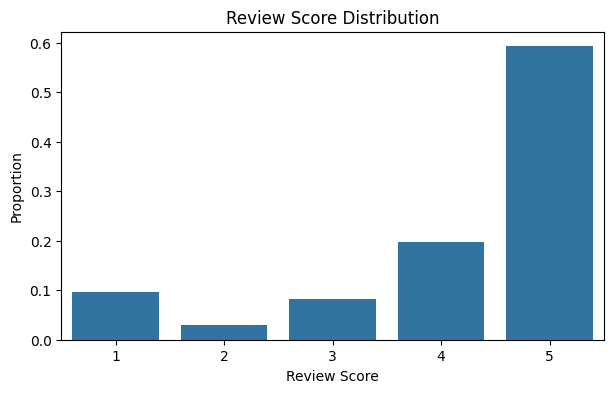

In [9]:
review_dist = df_order["review_score"].value_counts(normalize=True).sort_index()
display(review_dist)

plt.figure(figsize=(7, 4))
sns.barplot(x=review_dist.index, y=review_dist.values)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Proportion")
plt.show()

# 2단계) EDA(패턴 확인)

1. EDA 목적

- 배송이 늦으나 리뷰 높은 주 확인 -> AM, AP

- AM AP 특징 파악

2-1. 주 별 배송시간과 리뷰 -> AM, AP (배송느리지만 리뷰 높음)

- state_summary = df.groupby('customer_state').agg({'delivery_time':'mean','review_score':'mean','order_id':'count'})

- sns.scatterplot(data=state_summary,x='delivery_time',y='review_score')


2-2. AM, AP 특징 확인

- df[df['customer_state'].isin(['AM','AP'])].describe()

- 에서 distance price freight_value delivery_time product_category 확인변수

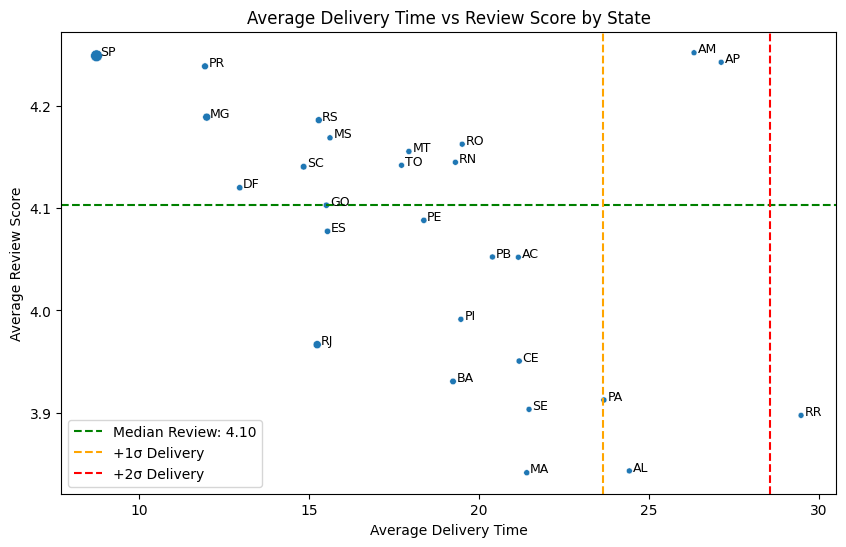

,customer_state,avg_delivery_time,avg_review_score,n_orders
25,SP,8.743234,4.248751,39642
18,RJ,15.236293,3.966539,11984
10,MG,11.985548,4.188831,11084
22,RS,15.282635,4.185864,5235
17,PR,11.935615,4.238462,4810
23,SC,14.836978,4.140376,3455
4,BA,19.232324,3.930621,3171
7,ES,15.539643,4.077280,1941
8,GO,15.506041,4.102754,1888
6,DF,12.957088,4.119872,1877


In [10]:
state_summary_delivery = (
    df_order.groupby("customer_state")
    .agg(
        avg_delivery_time=("delivery_time", "mean"),
        avg_review_score=("review_score", "mean"),
        n_orders=("order_id", "count")
    )
    .reset_index()
    .sort_values("n_orders", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=state_summary_delivery,
    x="avg_delivery_time",
    y="avg_review_score",
    size="n_orders",
    legend=False
)

for _, row in state_summary_delivery.iterrows():
    plt.text(
        row["avg_delivery_time"] + 0.1,
        row["avg_review_score"],
        row["customer_state"],
        fontsize=9
    )

# 기준선 계산
mean_delivery = state_summary_delivery["avg_delivery_time"].mean()
std_delivery = state_summary_delivery["avg_delivery_time"].std()
median_review = state_summary_delivery["avg_review_score"].median()

# 가로선 (리뷰 중앙값)
plt.axhline(
    y=median_review,
    color="green",
    linestyle="--",
    label=f"Median Review: {median_review:.2f}"
)

# 세로선 (배송시간 +1σ)
plt.axvline(
    x=mean_delivery + std_delivery,
    color="orange",
    linestyle="--",
    label="+1σ Delivery"
)

# 세로선 (배송시간 +2σ)
plt.axvline(
    x=mean_delivery + 2 * std_delivery,
    color="red",
    linestyle="--",
    label="+2σ Delivery"
)

plt.title("Average Delivery Time vs Review Score by State")
plt.xlabel("Average Delivery Time")
plt.ylabel("Average Review Score")
plt.legend()

plt.show()

state_summary_delivery

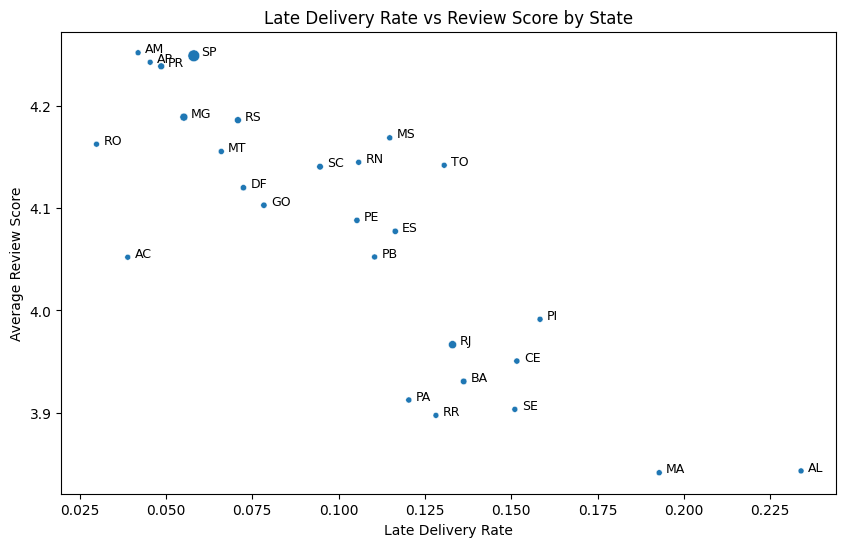

,customer_state,late_rate,avg_review_score,n_orders
25,SP,0.058095,4.248751,39642
18,RJ,0.133011,3.966539,11984
10,MG,0.055215,4.188831,11084
22,RS,0.070869,4.185864,5235
17,PR,0.048649,4.238462,4810
23,SC,0.094645,4.140376,3455
4,BA,0.136235,3.930621,3171
7,ES,0.116435,4.077280,1941
8,GO,0.078390,4.102754,1888
6,DF,0.072456,4.119872,1877


In [11]:
state_summary_late = (
    df_order.groupby("customer_state")
    .agg(
        late_rate=("is_delayed", "mean"),
        avg_review_score=("review_score", "mean"),
        n_orders=("order_id", "count")
    )
    .reset_index()
    .sort_values("n_orders", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=state_summary_late,
    x="late_rate",
    y="avg_review_score",
    size="n_orders",
    legend=False
)

for _, row in state_summary_late.iterrows():
    plt.text(
        row["late_rate"] + 0.002,
        row["avg_review_score"],
        row["customer_state"],
        fontsize=9
    )

plt.title("Late Delivery Rate vs Review Score by State")
plt.xlabel("Late Delivery Rate")
plt.ylabel("Average Review Score")
plt.show()

state_summary_late

In [12]:
# 1-2 AM / AP 특징 확인
target_states = ["AM", "AP"]
df_order["is_amap"] = df_order["customer_state"].isin(target_states)

df_amap = df_order[df_order["is_amap"]].copy()
df_non_amap = df_order[~df_order["is_amap"]].copy()

display(df_amap[[
    "distance",
    "delivery_time",
    "is_delayed",
    "total_price",
    "total_freight",
    "freight_ratio",
    "n_items",
    "n_sellers",
    "n_categories"
]].describe())

print("AM/AP 주문 수:", len(df_amap))
print("전체 주문 수:", len(df_order))
print("AM/AP 비중:", len(df_amap) / len(df_order))
print("AM/AP 평균 delivery_time:", df_amap["delivery_time"].mean())
print("기타 주 평균 delivery_time:", df_non_amap["delivery_time"].mean())
print("AM/AP late rate:", df_amap["is_delayed"].mean())
print("기타 주 late rate:", df_non_amap["is_delayed"].mean())

# 데이터규모 : AM+AP주문건 : 243건 (전체데이터는 109000건으로 전체에 대한 비중이 0.22%) - 굉장히 작은 특이 집단임
# 거리 : 평균 2671km의 거리 (전체 평균은 595로 이 곳은 전체의 배송거리 보다 4.4배가 김)
# 배송시간 : 평균 26.47 일 (전체 평균 12일로 전체에 비해 배송시간이 2배이상 걸림)
# 가격 : 평균 145, 중간값 89로 - 고가상품이 평균을 끌어올림 
# 배송비 : 평균 33.6 (전체 평균 20보다 높은 수준)

,distance,delivery_time,is_delayed,total_price,total_freight,freight_ratio,n_items,n_sellers,n_categories
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.0,209.0
mean,2628.838195,26.574708,0.043062,166.856268,38.515646,0.468328,1.148325,1.0,1.0
std,261.914457,16.657957,0.203485,238.893686,26.896237,0.390392,0.556439,0.0,0.0
min,809.161298,4.118403,0.000000,8.500000,0.000000,0.000000,1.000000,1.0,1.0
25%,2563.378476,19.871898,0.000000,49.990000,24.510000,0.204976,1.000000,1.0,1.0
50%,2677.535226,25.153704,0.000000,99.900000,29.400000,0.355365,1.000000,1.0,1.0
75%,2702.144505,31.450961,0.000000,179.900000,39.390000,0.593106,1.000000,1.0,1.0
max,3343.265169,187.203449,1.000000,1688.000000,213.090000,2.488235,5.000000,1.0,1.0


AM/AP 주문 수: 209
전체 주문 수: 94031
AM/AP 비중: 0.002222671246716508
AM/AP 평균 delivery_time: 26.574708433014354
기타 주 평균 delivery_time: 12.472547925538866
AM/AP late rate: 0.0430622009569378
기타 주 late rate: 0.0797893884163629


추가 가설: 거리가 배송시간에 영향을 미치고 배송시간이 리뷰에 영향을 주었다.

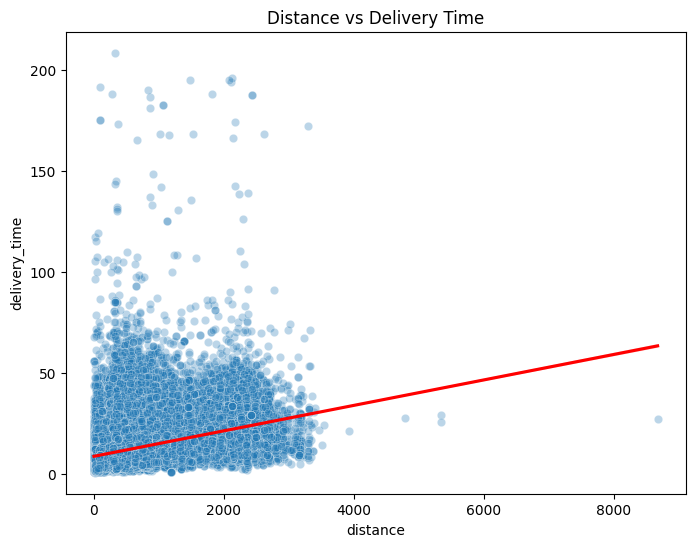

In [13]:
# 거리 vs 배송시간 관계

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="distance", y="delivery_time", alpha=0.3)

sns.regplot(data=df, x="distance", y="delivery_time", scatter=False, color="red")

plt.title("Distance vs Delivery Time")
plt.show()

In [14]:
# 거리 bin 분석

df["dist_bin"] = pd.cut(
    df["distance"],
    bins=[0,100,200,500,1000,2000,5000],
    labels=["0-100","100-200","200-500","500-1000","1000-2000","2000+"]
)

dist_summary = (
    df.groupby("dist_bin")
    .agg(
        avg_delivery=("delivery_time","mean"),
        avg_review=("review_score","mean"),
        n_orders=("order_id","count")
    )
)

dist_summary

,avg_delivery,avg_review,n_orders
dist_bin,,,
0-100,6.509665,4.222000,19973
100-200,8.726296,4.254555,7519
200-500,11.961872,4.066447,34012
500-1000,14.168176,4.036226,28902
1000-2000,17.831492,3.977854,10792
2000+,21.008429,3.925847,6082



3단계) 가설별 통계 분석

배송이 느린데, 리뷰가 왜 높은가?


가설1. 카테고리 때문일 것이다

카테고리 분포 비교

pd.crosstab(df['customer_state'],df['product_category_name_english'],normalize='index')

카이제곱 검정

from scipy.stats import chi2_contingency

chi2_contingency(pd.crosstab(df['customer_state'],df['product_category_name_english']))

*** 해석 : p < 0.05 → 카테고리 분포 차이 존재


가설2. 거리 때문일 것이다

거리 평균 비교

df.groupby('customer_state')['distance'].mean()

T-test

from scipy.stats import ttest_ind

ttest_ind(df[df.customer_state=='AM']['distance'],df[df.customer_state!='AM']['distance'])


가설3. 가격 영향

df.groupby('customer_state')['price'].mean()

검정

ttest_ind(df[df.customer_state=='AM']['price'],df[df.customer_state!='AM']['price'])


가설4 배송비 영향

df.groupby('customer_state')['freight_value'].mean()

검정

ttest_ind(df[df.customer_state=='AM']['freight_value'],df[df.customer_state!='AM']['freight_value'])


In [15]:
# 가설 1. 카테고리 영향
# 카테고리 확인
# AM/AP 지역 데이터
top_categories = df_order["main_category"].value_counts().head(15).index

df_order["category_grouped"] = np.where(
    df_order["main_category"].isin(top_categories),
    df_order["main_category"],
    "Other"
)

df_order["category_grouped"].value_counts().head(20)

# AM/AP 많이 구매한 카테고리 Top10
df_amap = df_order[df_order["is_amap"]].copy()

df_amap["category_grouped"].value_counts().head(10)

category_grouped
Other                    49
health_beauty            25
telephony                18
sports_leisure           18
watches_gifts            16
computers_accessories    16
bed_bath_table           10
toys                      9
housewares                8
garden_tools              7
Name: count, dtype: int64

In [16]:
# 각 주 별 카테고리 분포 확인하기 (order-level)
pd.crosstab(
    df_order["customer_state"],
    df_order["category_grouped"],
    normalize="index"
)

category_grouped,Other,auto,baby,bed_bath_table,computers_accessories,cool_stuff,electronics,furniture_decor,garden_tools,health_beauty,housewares,perfumery,sports_leisure,telephony,toys,watches_gifts
customer_state,,,,,,,,,,,,,,,,
AC,0.207792,0.051948,0.038961,0.038961,0.077922,0.012987,0.051948,0.077922,0.025974,0.077922,0.038961,0.038961,0.116883,0.051948,0.038961,0.051948
AL,0.172237,0.051414,0.017995,0.043702,0.082262,0.038560,0.030848,0.061697,0.030848,0.159383,0.020566,0.030848,0.079692,0.064267,0.030848,0.084833
AM,0.265734,0.027972,0.034965,0.048951,0.069930,0.027972,0.027972,0.027972,0.034965,0.104895,0.027972,0.013986,0.083916,0.097902,0.041958,0.062937
AP,0.166667,0.045455,0.000000,0.045455,0.090909,0.030303,0.045455,0.030303,0.030303,0.151515,0.060606,0.000000,0.090909,0.060606,0.045455,0.106061
BA,0.205929,0.045412,0.028698,0.065279,0.067487,0.041312,0.028382,0.061495,0.044150,0.099968,0.040681,0.025229,0.076947,0.067802,0.034374,0.066856
CE,0.182761,0.042298,0.023943,0.053472,0.061453,0.035116,0.031923,0.051077,0.035914,0.120511,0.035116,0.041500,0.068635,0.070231,0.047087,0.098962
DF,0.185402,0.052211,0.031433,0.085775,0.063932,0.036761,0.023442,0.051678,0.022376,0.107086,0.059137,0.038359,0.094832,0.038359,0.043154,0.066063
ES,0.189078,0.040701,0.031427,0.098403,0.069037,0.031427,0.035033,0.055641,0.042246,0.076765,0.050489,0.030397,0.079341,0.051520,0.046883,0.071613
GO,0.184852,0.037606,0.027542,0.098517,0.058263,0.041314,0.016949,0.051907,0.038665,0.108051,0.049788,0.041843,0.076801,0.058263,0.037076,0.072564


In [17]:
# Cramér's V 함수
def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

In [18]:
# 전체 주 비교 
# 카이제곱 독립성 검정 
# H0 : customer_state와 product_category는 서로 독립이다 -> 기각 : 주에 따라 구매 상품 카테고리 분포에는 통계적으로 유의한 차이가 존재한다 

table_all = pd.crosstab(
    df_order["customer_state"],
    df_order["category_grouped"]
)

chi2, p, dof, expected = chi2_contingency(table_all)
cv = cramers_v(table_all)

print("Chi2:", chi2)
print("p-value:", p)
print("dof:", dof)
print("Cramer's V:", cv)

Chi2: 1855.4870977973733
p-value: 5.562388407150876e-189
dof: 390
Cramer's V: 0.036270021456242106


In [19]:
# AM/AP vs 다른 주 비교

# H0 : AM/AP 여부와 카테고리는 독립이다 -> p값으로 기각됨 : AM/AP 지역 소비패턴이 다른 지역과 다를 가능성이 큼

# AM/AP 여부 변수 생성 (True면 AM/AP False면 다른 주) + 상품 카테고리 교차표 생성
table_amap = pd.crosstab(
    df_order["is_amap"],
    df_order["category_grouped"]
)

chi2, p, dof, expected = chi2_contingency(table_amap)
cv = cramers_v(table_amap)

print("Chi2:", chi2)
print("p-value:", p)
print("dof:", dof)
print("Cramer's V:", cv)

Chi2: 29.994936711854102
p-value: 0.011939766728462614
dof: 15
Cramer's V: 0.017860287584888602


In [20]:
# AM/AP에서 많이 팔리는 카테고리 Top10
for st in ["AM", "AP"]:
    print(f"\n[{st}] Top categories")
    display(
        df_order.loc[df_order["customer_state"] == st, "category_grouped"]
        .value_counts(normalize=True)
        .head(10)
    )


[AM] Top categories


category_grouped
Other                    0.265734
health_beauty            0.104895
telephony                0.097902
sports_leisure           0.083916
computers_accessories    0.069930
watches_gifts            0.062937
bed_bath_table           0.048951
toys                     0.041958
garden_tools             0.034965
baby                     0.034965
Name: proportion, dtype: float64


[AP] Top categories


category_grouped
Other                    0.166667
health_beauty            0.151515
watches_gifts            0.106061
computers_accessories    0.090909
sports_leisure           0.090909
telephony                0.060606
housewares               0.060606
auto                     0.045455
bed_bath_table           0.045455
toys                     0.045455
Name: proportion, dtype: float64

In [21]:
# 비교 함수
# 거리, 가격, 배송비 등 비교용
def cohens_d(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled_std = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (x.mean() - y.mean()) / pooled_std

def compare_amap_continuous(df_in, col):
    x = df_in.loc[df_in["is_amap"], col].dropna()
    y = df_in.loc[~df_in["is_amap"], col].dropna()

    t_stat, t_p = ttest_ind(x, y, equal_var=False)
    u_stat, u_p = mannwhitneyu(x, y, alternative="two-sided")
    d = cohens_d(x, y)

    return pd.Series({
        "amap_mean": x.mean(),
        "other_mean": y.mean(),
        "ttest_p": t_p,
        "mannwhitney_p": u_p,
        "cohens_d": d,
        "amap_n": len(x),
        "other_n": len(y)
    })

# 이진형 비교 함수
def compare_amap_binary(df_in, col):
    table = pd.crosstab(df_in["is_amap"], df_in[col])
    chi2, p, dof, expected = chi2_contingency(table)

    return pd.Series({
        "amap_rate": df_in.loc[df_in["is_amap"], col].mean(),
        "other_rate": df_in.loc[~df_in["is_amap"], col].mean(),
        "chi2_p": p
    })

In [22]:
# 가설 비교 요약
compare_results_cont = pd.DataFrame({
    "distance": compare_amap_continuous(df_order, "distance"),
    "delivery_time": compare_amap_continuous(df_order, "delivery_time"),
    "total_price": compare_amap_continuous(df_order, "total_price"),
    "total_freight": compare_amap_continuous(df_order, "total_freight"),
    "freight_ratio": compare_amap_continuous(df_order, "freight_ratio")
}).T

compare_results_cont

,amap_mean,other_mean,ttest_p,mannwhitney_p,cohens_d,amap_n,other_n
distance,2628.838195,596.523240,1.085188e-190,3.481274e-133,3.469668,209.0,93822.0
delivery_time,26.574708,12.472548,2.727245e-26,5.025044e-70,1.495537,209.0,93822.0
total_price,166.856268,136.890802,7.144583e-02,2.752741e-02,0.144124,209.0,93822.0
total_freight,38.515646,22.755447,4.532113e-15,7.182277e-58,0.730395,209.0,93822.0
freight_ratio,0.468328,0.308081,1.242034e-08,4.398965e-14,0.515279,209.0,93822.0


In [23]:
compare_results_binary = pd.DataFrame({
    "is_late": compare_amap_binary(df_order, "is_delayed")
}).T

compare_results_binary

,amap_rate,other_rate,chi2_p
is_late,0.043062,0.079789,0.067191


리뷰 점수는 ordinal scale이므로 정규성을 가정하는 t-test와 non-parametric test인 Mann-Whitney U test를 같이 사용해서 보았다.
가설 2. 거리 영향
H0 : AM 지역은 다른 지역보다 배송 거리가 같다. -> 기각 : 배송거리가 다르다.
가설 3️. 가격 영향
H0 : AM 지역과 타지역 상품 가격은 같다 -> 기각 실패 : AM 지역과 다른 지역간 상품 가격 차이는 통계적으로 유의하지 않았다.
가설 4. 배송비 영향 
H0 : AM 지역과 다른 지역의 평균 배송비(freight_value)는 같다. -> 기각 : AM 지역과 다른 지역의 평균 배송비가 유의미한 차이를 가지고 있다.
배송비 비율 vs 리뷰
H0 : AM 지역과 다른 지역의 평균 배송비율(freight_ratio)는 같다. -> 기각 : AM 지역과 다른 지역의 평균 배송비가 유의미한 차이를 가지고 있다.



4단계) 상관분석
목적 : 리뷰에 영향 변수 확인
* Spearman correlation 사용 (리뷰점수는 ordinal)
df[['review_score','delivery_time','distance','price','freight_ratio']].corr(method='spearman')



In [24]:
# 상관 분석 (리뷰점수는 ordinal데이터 -> spearman 사용)
corr_cols = [
    "review_score",
    "is_delayed",
    "distance",
    "total_price",
    "total_freight",
    "freight_ratio",
    "n_items",
    "n_sellers",
    "n_categories"
]

corr, pval = spearmanr(df_order[corr_cols])

corr_df = pd.DataFrame(corr, index=corr_cols, columns=corr_cols)
pval_df = pd.DataFrame(pval, index=corr_cols, columns=corr_cols)

display(corr_df)
display(pval_df)

,review_score,is_delayed,distance,total_price,total_freight,freight_ratio,n_items,n_sellers,n_categories
review_score,1.000000,-0.293741,-0.065201,-0.028179,-0.089184,-0.032277,-0.106825,-0.094067,-0.060365
is_delayed,-0.293741,1.000000,0.058730,0.018164,0.042667,0.004175,-0.019989,-0.028258,-0.018553
distance,-0.065201,0.058730,1.000000,0.110746,0.583579,0.218410,-0.014209,-0.002062,-0.002527
total_price,-0.028179,0.018164,0.110746,1.000000,0.471514,-0.784299,0.179265,0.084501,0.065374
total_freight,-0.089184,0.042667,0.583579,0.471514,1.000000,0.101844,0.376479,0.140895,0.107030
freight_ratio,-0.032277,0.004175,0.218410,-0.784299,0.101844,1.000000,0.081543,0.017423,0.014503
n_items,-0.106825,-0.019989,-0.014209,0.179265,0.376479,0.081543,1.000000,0.346072,0.264134
n_sellers,-0.094067,-0.028258,-0.002062,0.084501,0.140895,0.017423,0.346072,1.000000,0.597721
n_categories,-0.060365,-0.018553,-0.002527,0.065374,0.107030,0.014503,0.264134,0.597721,1.000000


,review_score,is_delayed,distance,total_price,total_freight,freight_ratio,n_items,n_sellers,n_categories
review_score,0.000000e+00,0.000000e+00,4.100041e-89,5.495601e-18,2.601662e-165,4.163513e-23,1.104657e-236,9.217412e-184,1.241803e-76
is_delayed,0.000000e+00,0.000000e+00,1.251964e-72,2.542808e-08,3.785893e-39,2.004260e-01,8.779471e-10,4.442110e-18,1.273434e-08
distance,4.100041e-89,1.251964e-72,0.000000e+00,2.506760e-254,0.000000e+00,0.000000e+00,1.316240e-05,5.272729e-01,4.383893e-01
total_price,5.495601e-18,2.542808e-08,2.506760e-254,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.480242e-148,1.407969e-89
total_freight,2.601662e-165,3.785893e-39,0.000000e+00,0.000000e+00,0.000000e+00,3.295678e-215,0.000000e+00,0.000000e+00,1.375177e-237
freight_ratio,4.163513e-23,2.004260e-01,0.000000e+00,0.000000e+00,3.295678e-215,0.000000e+00,1.919433e-138,9.148589e-08,8.691496e-06
n_items,1.104657e-236,8.779471e-10,1.316240e-05,0.000000e+00,0.000000e+00,1.919433e-138,0.000000e+00,0.000000e+00,0.000000e+00
n_sellers,9.217412e-184,4.442110e-18,5.272729e-01,1.480242e-148,0.000000e+00,9.148589e-08,0.000000e+00,0.000000e+00,0.000000e+00
n_categories,1.241803e-76,1.273434e-08,4.383893e-01,1.407969e-89,1.375177e-237,8.691496e-06,0.000000e+00,0.000000e+00,0.000000e+00


In [25]:
r, p = spearmanr(df_order["is_delayed"], df_order["review_score"])
print("Spearman r (is_delayed vs review_score):", r)
print("p-value:", p)

Spearman r (is_delayed vs review_score): -0.29374115577215093
p-value: 0.0


### 추가 분석: 거리와 배송시간의 관계

앞선 상관분석에서는 거리가 리뷰 점수와 강한 직접적인 상관관계를 보이지 않았다.

하지만 이는 거리가 리뷰에 영향을 주지 않는다는 의미가 아니라,
거리가 배송시간을 증가시키고 배송시간이 다시 리뷰 점수에 영향을 미치는
간접적인 구조일 가능성을 의미할 수 있다.

따라서 거리와 배송시간 간의 관계를 추가적으로 확인한다.

In [26]:
r, p = spearmanr(df["distance"], df["delivery_time"])

print("Spearman r:", r)
print("p-value:", p)

Spearman r: 0.5398589149490515
p-value: 0.0


- 관계가 꽤 강하게 존재함.(거리와 배송시간은 중간 이상의 양의 상관관계를 보인다.)
- 거리와 배송시간 사이에는 통계적으로 유의미한 관계가 존재한다.
- 즉, 거리는 리뷰에 직접 영향을 주기보다는 배송시간을 통해 간접적으로 영향을 미칠 가능성이 있다.

5단계) 머신러닝 모델
목적 : 리뷰점수를 설명하는 핵심 변수 확인
타겟 : review_score
피처 :
delivery_time distance price freight_value freight_ratio product_category

5-1 모델 데이터 준비
X = df[['delivery_time','distance','price','freight_ratio']]
y = df['review_score']

5-2 train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

5-3 
모델 1 RandomForest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)

모델 2 XGBOOST

5-4 feature importance
pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)


- 본 분석에서는 order_item 단위 데이터를 사용하여 통계적 관계를 확인하였다.
- 다만 머신러닝 모델에서는 동일 주문에 대한 중복 샘플을 방지하기 위해 order 단위로 데이터를 집계하여 사용하였다.
- 근거: item level에서 분석의 관계 자체는 order level과 동일한 관계이다
-     그래서 aggregation을 해도 논리가 유지됨. 즉 정보 손실 없는 것임.

In [27]:
display(df_order[[
    "review_score",
    "distance",
    "delivery_time",
    "delay_days",
    "is_delayed",
    "total_price",
    "freight_ratio",
    "main_category"
]].describe(include="all"))

,review_score,distance,delivery_time,delay_days,is_delayed,total_price,freight_ratio,main_category
count,94031.000000,94031.000000,94031.000000,94031.000000,94031.000000,94031.000000,94031.000000,94031
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bed_bath_table
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9128
mean,4.157023,601.040408,12.503892,-11.229842,0.079708,136.957405,0.308438,NaN
std,1.283501,593.502283,9.452805,10.114583,0.270842,207.917870,0.311080,NaN
min,1.000000,0.000000,0.533414,-146.016123,0.000000,0.850000,0.000000,NaN
25%,4.000000,187.561623,6.746829,-16.256372,0.000000,45.900000,0.132324,NaN
50%,5.000000,434.281323,10.196146,-11.986655,0.000000,85.940000,0.224545,NaN
75%,5.000000,798.999683,15.632402,-6.409931,0.000000,149.900000,0.380583,NaN


In [28]:
feature_set_A = [
    "distance",
    "total_price",
    "delivery_time",
    "freight_ratio",
    "main_category"
]

df_model_A = df_order[["review_score"] + feature_set_A].dropna().copy()

X_A = df_model_A[feature_set_A].copy()
y_A = df_model_A["review_score"].copy()

print(X_A.columns.tolist())
print(X_A.shape)

['distance', 'total_price', 'delivery_time', 'freight_ratio', 'main_category']
(94031, 5)


In [29]:
feature_set_B = [
    "distance",
    "total_price",
    "delivery_time",
    "freight_ratio",
    "main_category",
    "is_delayed",
    "delay_days"
]

df_model_B = df_order[["review_score"] + feature_set_B].dropna().copy()

X_B = df_model_B[feature_set_B].copy()
y_B = df_model_B["review_score"].copy()

print(X_B.columns.tolist())
print(X_B.shape)

['distance', 'total_price', 'delivery_time', 'freight_ratio', 'main_category', 'is_delayed', 'delay_days']
(94031, 7)


In [30]:
def make_split(X, y):
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

In [31]:
# 세트 A split
X_train_A, X_test_A, y_train_A, y_test_A = make_split(X_A, y_A)

print(X_train_A.shape, X_test_A.shape)
print(X_train_A.columns.tolist())

(75224, 5) (18807, 5)
['distance', 'total_price', 'delivery_time', 'freight_ratio', 'main_category']


In [32]:
# 세트 B split
X_train_B, X_test_B, y_train_B, y_test_B = make_split(X_B, y_B)

print(X_train_B.shape, X_test_B.shape)
print(X_train_B.columns.tolist())

(75224, 7) (18807, 7)
['distance', 'total_price', 'delivery_time', 'freight_ratio', 'main_category', 'is_delayed', 'delay_days']


In [33]:
# 전처리 함수
def make_preprocessor(numeric_features, categorical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat_te", ce.TargetEncoder(cols=categorical_features), categorical_features)
        ],
        remainder="drop"
    )
    return preprocessor

In [34]:
numeric_features_A = [
    "distance",
    "total_price",
    "delivery_time",
    "freight_ratio"
]

categorical_features_A = ["main_category"]

preprocessor_A = make_preprocessor(numeric_features_A, categorical_features_A)

In [35]:
numeric_features_B = [
    "distance",
    "total_price",
    "delivery_time",
    "freight_ratio",
    "is_delayed",
    "delay_days"
]

categorical_features_B = ["main_category"]

preprocessor_B = make_preprocessor(numeric_features_B, categorical_features_B)

In [36]:
# 평가 함수
def evaluate_model(model, X_test, y_test, model_name, feature_set_name):
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)

    return pd.DataFrame({
        "feature_set": [feature_set_name],
        "model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })

### Random Forest

In [37]:
def fit_random_forest(preprocessor, X_train, y_train):
    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    param_grid_rf = {
        "model__n_estimators": [200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"]
    }

    grid_search_rf = GridSearchCV(
        rf_pipeline,
        param_grid=param_grid_rf,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    grid_search_rf.fit(X_train, y_train)

    return grid_search_rf

In [38]:
# 세트 A - Random Forest 학습
grid_rf_A = fit_random_forest(preprocessor_A, X_train_A, y_train_A)

best_rf_A = grid_rf_A.best_estimator_
print("Best RF A Params:", grid_rf_A.best_params_)

Best RF A Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [39]:
# 세트 A - RF 평가
result_rf_A = evaluate_model(best_rf_A, X_test_A, y_test_A, "RandomForest", "Set_A")
result_rf_A

,feature_set,model,MAE,RMSE,R2
0,Set_A,RandomForest,0.902392,1.173524,0.164095


In [40]:
# 세트 B - Random Forest 학습
grid_rf_B = fit_random_forest(preprocessor_B, X_train_B, y_train_B)

best_rf_B = grid_rf_B.best_estimator_
print("Best RF B Params:", grid_rf_B.best_params_)

Best RF B Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [41]:
# 세트 B - RF 평가
result_rf_B = evaluate_model(best_rf_B, X_test_B, y_test_B, "RandomForest", "Set_B")
result_rf_B

,feature_set,model,MAE,RMSE,R2
0,Set_B,RandomForest,0.881711,1.154209,0.191385


### XGBoost

In [42]:
def fit_xgboost(preprocessor, X_train, y_train):
    xgb_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])

    param_grid_xgb = {
        "model__n_estimators": [200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }

    grid_search_xgb = GridSearchCV(
        xgb_pipeline,
        param_grid=param_grid_xgb,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    grid_search_xgb.fit(X_train, y_train)

    return grid_search_xgb

In [43]:
# 세트 A - XGBoost 학습
grid_xgb_A = fit_xgboost(preprocessor_A, X_train_A, y_train_A)

best_xgb_A = grid_xgb_A.best_estimator_
print("Best XGB A Params:", grid_xgb_A.best_params_)

Best XGB A Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}


In [44]:
# 세트 A - XGB 평가
result_xgb_A = evaluate_model(best_xgb_A, X_test_A, y_test_A, "XGBoost", "Set_A")
result_xgb_A

,feature_set,model,MAE,RMSE,R2
0,Set_A,XGBoost,0.898555,1.172569,0.165455


In [45]:
# 세트 B - XGBoost 학습
grid_xgb_B = fit_xgboost(preprocessor_B, X_train_B, y_train_B)

best_xgb_B = grid_xgb_B.best_estimator_
print("Best XGB B Params:", grid_xgb_B.best_params_)

Best XGB B Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [46]:
# 세트 B - XGB 평가
result_xgb_B = evaluate_model(best_xgb_B, X_test_B, y_test_B, "XGBoost", "Set_B")
result_xgb_B

,feature_set,model,MAE,RMSE,R2
0,Set_B,XGBoost,0.878613,1.151962,0.194531


In [47]:
# Dummy baseline 함수
def evaluate_dummy(y_train, y_test, feature_set_name):
    dummy = DummyRegressor(strategy="mean")
    dummy.fit(np.zeros((len(y_train), 1)), y_train)

    pred = dummy.predict(np.zeros((len(y_test), 1)))

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)

    return pd.DataFrame({
        "feature_set": [feature_set_name],
        "model": ["Dummy"],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })

In [48]:
# 세트 A Dummy
result_dummy_A = evaluate_dummy(y_train_A, y_test_A, "Set_A")
result_dummy_A

,feature_set,model,MAE,RMSE,R2
0,Set_A,Dummy,0.998882,1.283552,-3.397390e-09


In [49]:
# 세트 B Dummy
result_dummy_B = evaluate_dummy(y_train_B, y_test_B, "Set_B")
result_dummy_B

,feature_set,model,MAE,RMSE,R2
0,Set_B,Dummy,0.998882,1.283552,-3.397390e-09


In [50]:
results_all = pd.concat([
    result_dummy_A,
    result_rf_A,
    result_xgb_A,
    result_dummy_B,
    result_rf_B,
    result_xgb_B
], ignore_index=True)

results_all

,feature_set,model,MAE,RMSE,R2
0,Set_A,Dummy,0.998882,1.283552,-3.397390e-09
1,Set_A,RandomForest,0.902392,1.173524,1.640954e-01
2,Set_A,XGBoost,0.898555,1.172569,1.654554e-01
3,Set_B,Dummy,0.998882,1.283552,-3.397390e-09
4,Set_B,RandomForest,0.881711,1.154209,1.913852e-01
5,Set_B,XGBoost,0.878613,1.151962,1.945308e-01



6단계) Feature Importance 해석

: 거리 영향이 가장 큼

### Random Forest Feature importance & SHAP

In [51]:
# SHAP 확인 함수
def get_transformed_feature_names(preprocessor, input_features):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder":
            continue

        # Pipeline 안에 들어있는 경우
        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
        else:
            last_step = transformer

        # OneHotEncoder 같은 경우
        if hasattr(last_step, "get_feature_names_out"):
            try:
                names = last_step.get_feature_names_out(cols)
            except:
                names = last_step.get_feature_names_out()
            feature_names.extend(names)
        else:
            # scaler 등은 원래 컬럼명 유지
            if isinstance(cols, (list, tuple, np.ndarray)):
                feature_names.extend(cols)
            else:
                feature_names.append(cols)

    return feature_names


def make_transformed_df(fitted_pipeline, X):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]

    X_transformed = preprocessor.transform(X)
    feature_names = get_transformed_feature_names(preprocessor, X.columns)

    # sparse matrix 대응
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )

    return preprocessor, model, X_transformed_df


def compute_shap_tree(fitted_pipeline, X_sample):
    preprocessor, model, X_transformed_df = make_transformed_df(fitted_pipeline, X_sample)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed_df)

    return explainer, shap_values, X_transformed_df, model


def plot_shap_all(fitted_pipeline, X_sample, max_display=15, target_feature=None):
    explainer, shap_values, X_transformed_df, model = compute_shap_tree(fitted_pipeline, X_sample)

    # 회귀: shap_values가 2차원 배열
    # 분류: 클래스별 리스트일 수 있음
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_values_plot = shap_values

    print("Model:", type(model).__name__)
    print("X transformed shape:", X_transformed_df.shape)

    # 1) summary beeswarm
    plt.figure()
    shap.summary_plot(shap_values_plot, X_transformed_df, max_display=max_display, show=False)
    plt.tight_layout()
    plt.show()

    # 2) mean |SHAP| bar
    plt.figure()
    shap.summary_plot(shap_values_plot, X_transformed_df, plot_type="bar", max_display=max_display, show=False)
    plt.tight_layout()
    plt.show()

    # 3) dependence plot
    if target_feature is not None and target_feature in X_transformed_df.columns:
        shap.dependence_plot(target_feature, shap_values_plot, X_transformed_df)
        plt.tight_layout()
        plt.show()
    elif target_feature is not None:
        print(f"'{target_feature}' 컬럼이 변환 후 feature에 없습니다.")
        print("사용 가능한 feature 예시:", X_transformed_df.columns[:20].tolist())

    return explainer, shap_values_plot, X_transformed_df

,feature,importance
2,delivery_time,0.696116
0,distance,0.111506
3,freight_ratio,0.069833
1,total_price,0.067968
4,main_category_te,0.054577


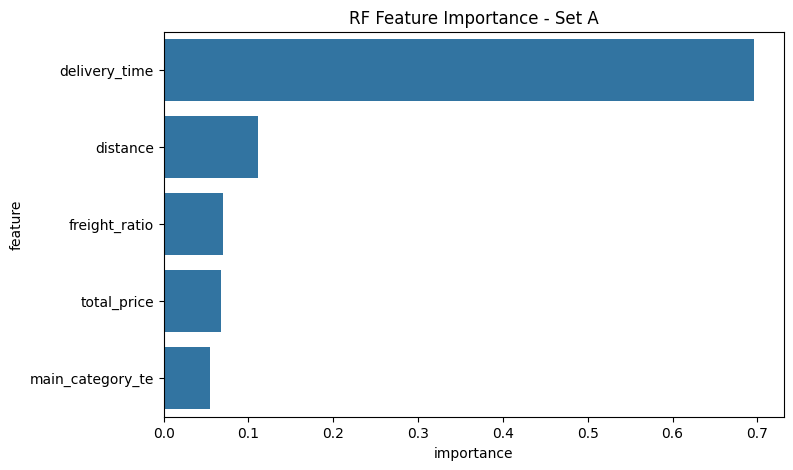

In [52]:
# 세트 A Random Forest 중요도
feature_names_A = numeric_features_A + ["main_category_te"]

importances_rf_A = best_rf_A.named_steps["model"].feature_importances_

importance_df_rf_A = (
    pd.DataFrame({
        "feature": feature_names_A,
        "importance": importances_rf_A
    })
    .sort_values("importance", ascending=False)
)

display(importance_df_rf_A)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df_rf_A, x="importance", y="feature")
plt.title("RF Feature Importance - Set A")
plt.show()

Model: RandomForestRegressor
X transformed shape: (18807, 5)


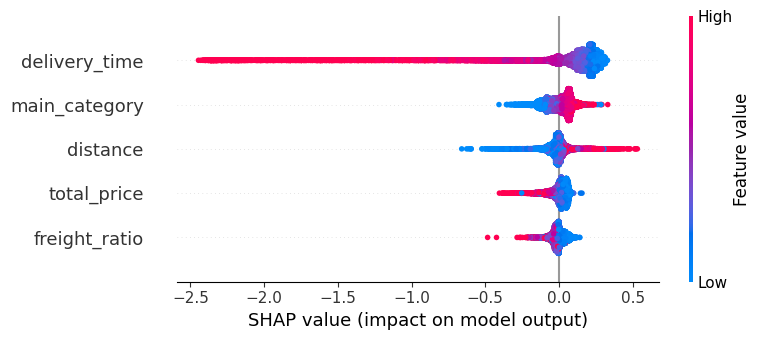

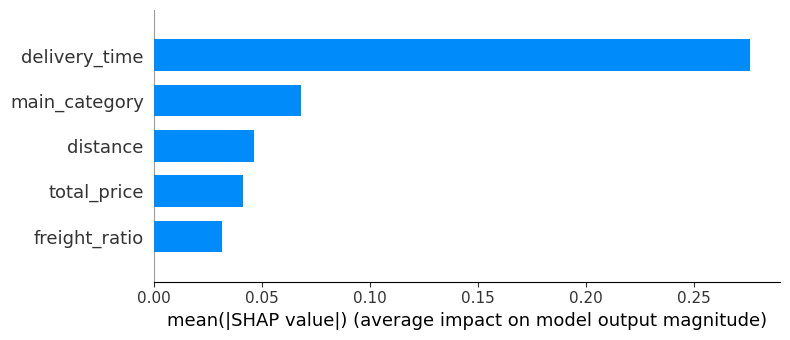

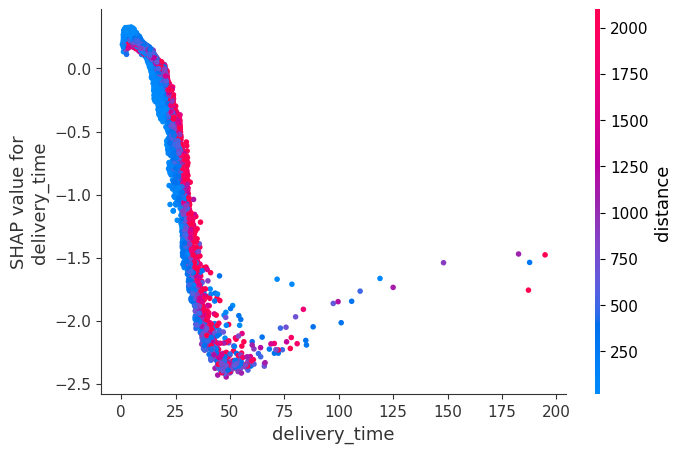

<Figure size 640x480 with 0 Axes>

In [53]:
# 세트 A Random Forest SHAP
explainer_rf_a, shap_rf_a, X_rf_a = plot_shap_all(
    fitted_pipeline=best_rf_A,
    X_sample=X_test_A,
    max_display=15,
    target_feature="delivery_time"
)

,feature,importance
5,delay_days,0.405123
2,delivery_time,0.227145
4,is_delayed,0.193806
0,distance,0.046734
1,total_price,0.043545
3,freight_ratio,0.042996
6,main_category_te,0.040649


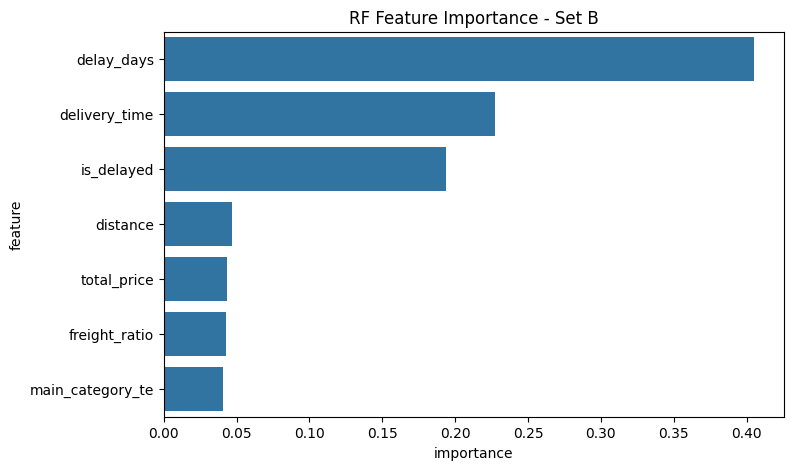

In [54]:
# 세트 B Random Forest 중요도
feature_names_B = numeric_features_B + ["main_category_te"]

importances_rf_B = best_rf_B.named_steps["model"].feature_importances_

importance_df_rf_B = (
    pd.DataFrame({
        "feature": feature_names_B,
        "importance": importances_rf_B
    })
    .sort_values("importance", ascending=False)
)

display(importance_df_rf_B)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df_rf_B, x="importance", y="feature")
plt.title("RF Feature Importance - Set B")
plt.show()

Model: RandomForestRegressor
X transformed shape: (18807, 7)


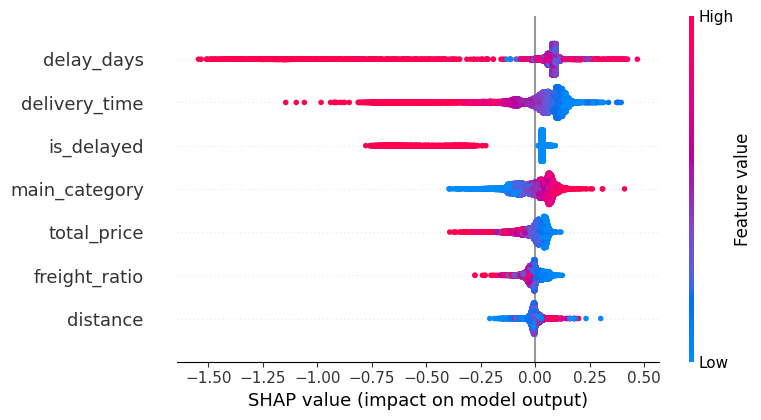

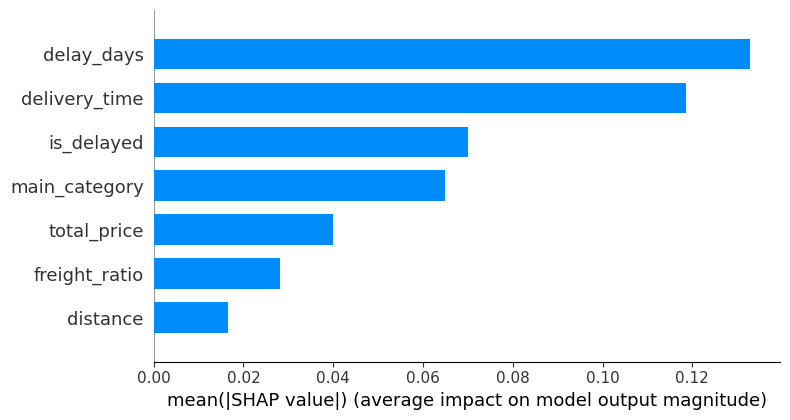

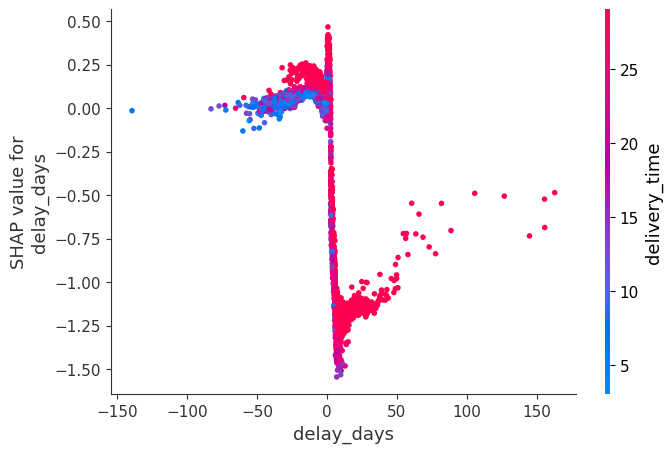

<Figure size 640x480 with 0 Axes>

In [55]:
# 세트 B Random Forest SHAP
explainer_rf_b, shap_rf_b, X_rf_b = plot_shap_all(
    fitted_pipeline=best_rf_B,
    X_sample=X_test_B,
    max_display=15,
    target_feature="delay_days"
)

### XGBOOST Feature importance & SHAP

,feature,importance
2,delivery_time,0.669130
0,distance,0.112573
4,main_category_te,0.083731
3,freight_ratio,0.067804
1,total_price,0.066762


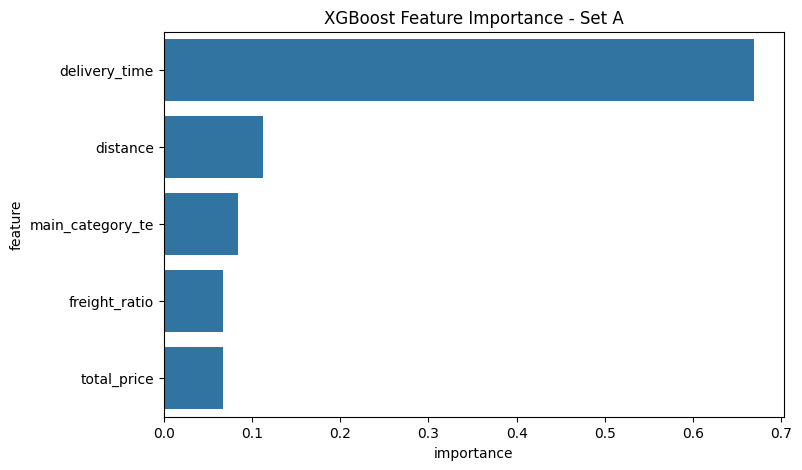

In [56]:
# 세트 A XGBoost 중요도
importances_xgb_A = best_xgb_A.named_steps["model"].feature_importances_

importance_df_xgb_A = (
    pd.DataFrame({
        "feature": feature_names_A,
        "importance": importances_xgb_A
    })
    .sort_values("importance", ascending=False)
)

display(importance_df_xgb_A)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df_xgb_A, x="importance", y="feature")
plt.title("XGBoost Feature Importance - Set A")
plt.show()

Model: XGBRegressor
X transformed shape: (18807, 5)


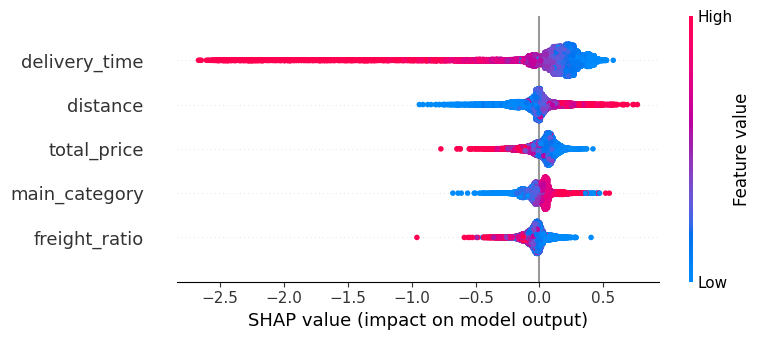

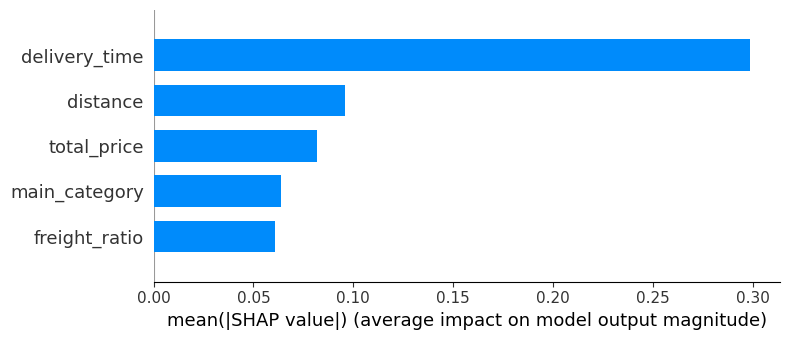

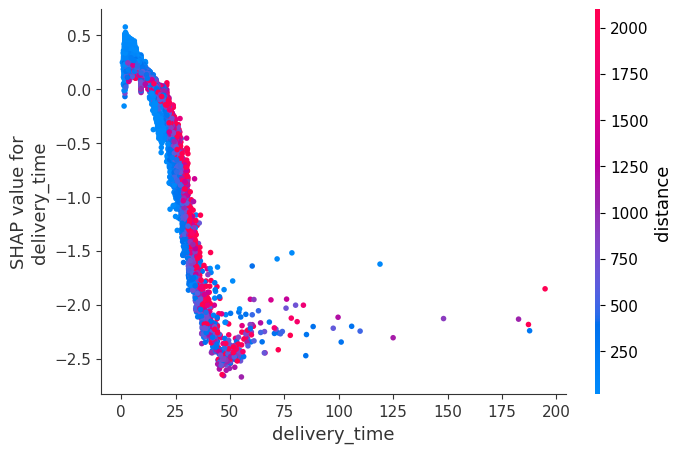

<Figure size 640x480 with 0 Axes>

In [57]:
# 세트 A XGBoost SHAP
explainer_xgb_a, shap_xgb_a, X_xgb_a = plot_shap_all(
    fitted_pipeline=best_xgb_A,
    X_sample=X_test_A,
    max_display=15,
    target_feature="delivery_time"
)

,feature,importance
5,delay_days,0.789899
2,delivery_time,0.084970
6,main_category_te,0.041978
3,freight_ratio,0.029971
1,total_price,0.028020
0,distance,0.025161
4,is_delayed,0.000000


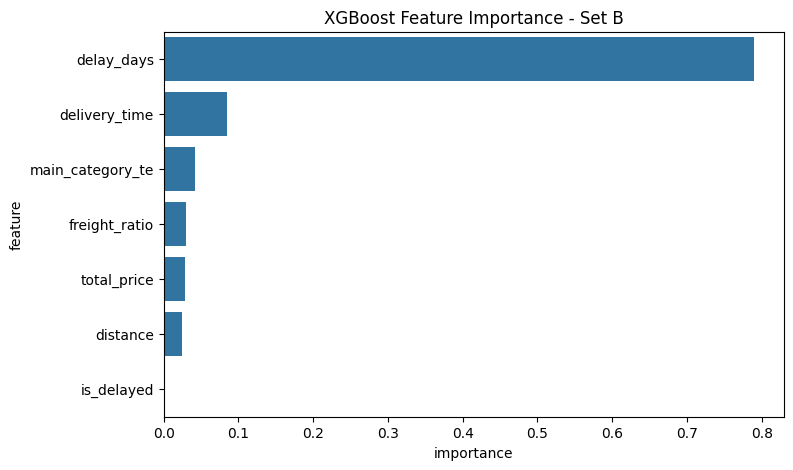

In [58]:
# 세트 B XGBoost 중요도
importances_xgb_B = best_xgb_B.named_steps["model"].feature_importances_

importance_df_xgb_B = (
    pd.DataFrame({
        "feature": feature_names_B,
        "importance": importances_xgb_B
    })
    .sort_values("importance", ascending=False)
)

display(importance_df_xgb_B)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df_xgb_B, x="importance", y="feature")
plt.title("XGBoost Feature Importance - Set B")
plt.show()

Model: XGBRegressor
X transformed shape: (18807, 7)


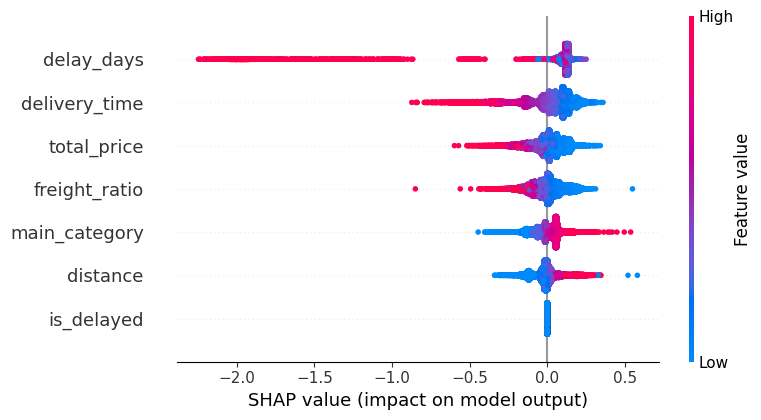

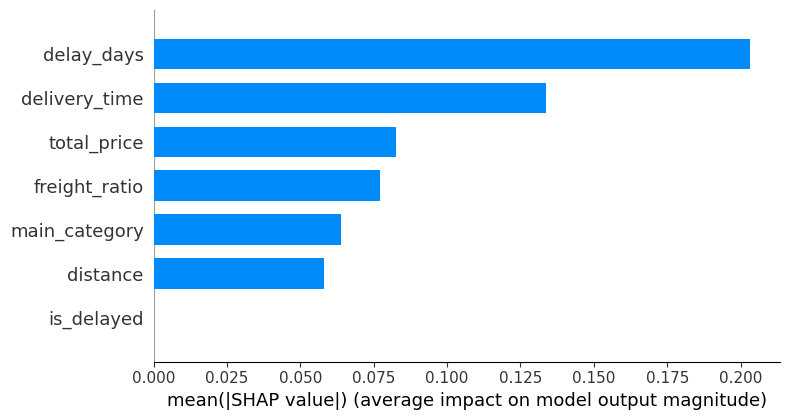

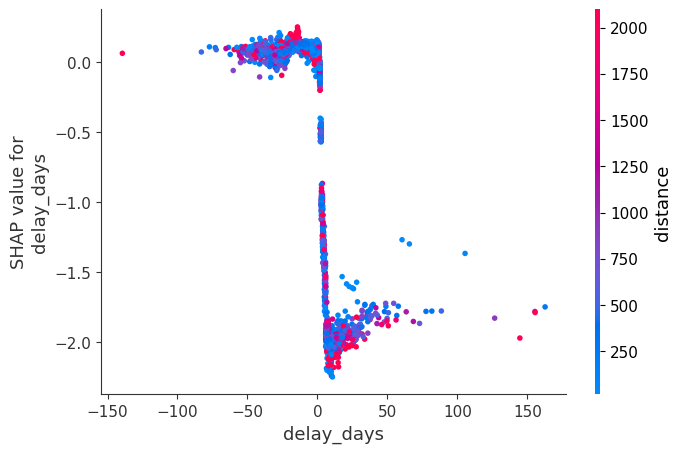

<Figure size 640x480 with 0 Axes>

In [59]:
# 세트 B XGBoost SHAP
explainer_xgb_b, shap_xgb_b, X_xgb_b = plot_shap_all(
    fitted_pipeline=best_xgb_B,
    X_sample=X_test_B,
    max_display=15,
    target_feature="delay_days"
)

In [60]:
final_compare = results_all.pivot(index="feature_set", columns="model", values="MAE")
final_compare

model,Dummy,RandomForest,XGBoost
feature_set,,,
Set_A,0.998882,0.902392,0.898555
Set_B,0.998882,0.881711,0.878613


### 모델의 Test R2  : 0.16, 0.19 모델이 데이터를 제대로 설명 못하는데 안좋은 모델이 아닌가?
1. baseline과 비교
※ baseline이란: "아무것도 학습하지 않아도 낼 수 있는 최소한의 성능"

- Dummy MAE = 1.001
- 위의 모델이 baseline 모델에 비해서 평균에러를 0.16, 0.19 리뷰 스코어 만큼 줄여준다.
- 단순 평균 예측 모델 대비 약 16%, 19%의 오류 감소가 나타났기 때문에, 모델은 실제로 데이터에서 의미 있는 패턴을 학습하고 있다고 볼 수 있습니다.

2. Review score의 구조적 문제
리뷰 점수가 매우 한쪽으로 치우쳐 있기 때문에 설명 가능한 분산 자체가 작으며, 이로 인해 R²가 낮게 나타나는 것이 자연스럽다.

In [61]:
df["review_score"].value_counts(normalize=True).sort_index()

review_score
1    0.113626
2    0.033539
3    0.084327
4    0.192586
5    0.575922
Name: proportion, dtype: float64

3. 설명 변수 한계(데이터의 한계)
리뷰는 실제로 Olist데이터에 들어있는 feature들 말고도 다음에 영향을 받습니다.
- product quality
- expectation mismatch
- seller communication
- defective item
- packaging
- customer personality

#### 다만, R²가 낮다는 것은 우리가 가진 변수들이 전체 현상을 모두 설명하지 못한다는 뜻이지, 그 변수들이 의미가 없다는 뜻은 아니다.
Baseline 대비 개선은 실제 feature target 사이에 실제 정보가 존재한다는 의미이기에, feature importance를 보는 것은 의미가 있다.


* 최종 인사이트

- 고객 리뷰 점수에 영향을 미치는 주요 요인을 파악하기 위해 2가지 Feature 세트를 구성하여 머신러닝 모델을 비교하였다.

- (A)SET는 5가지의 변수 : 배송거리, 배송시간, 가격, 배송비 비중, 상품카테고리
- (B)SET는 7가지의 변수로, (A)SET에 +배송지연 파생변수(지연여부, 지연일수)를 추가 구성한 SET이다.
- 각 Feature Set에 2가지 모델(Random Forest와 XGBoost)을 학습하여 변수 중요도를 비교하였다.

- 변수중요도 분석 결과
- 두 모델 모두에서 배송 관련 변수가 고객 리뷰 점수에 가장 큰 영향을 미치는 것으로 나타났다.

- SET(A)의 경우 두 모델에서 배송시간이 가장 높응ㄴ 중요도를 보였다.
- SET(B)의 경우, 배송지연관련변수가 추가되며 변수 중요도 구조가 변화하였는데, 특히 배송지연일수가 두 모델 모두에서 가장 높은 중요도를 보였으며, 
- 이는 단순 배송 소요시간보다 예상배송일 대비 실제 배송지연 여부와 지연 정도에서 더 직접적인 영향을 미친다는 것을 의미하고, 또한 배송시간 역시 여전히 높은 중요도를 보여, 배송소요시간 또한 고객 만족도에 영향을 주는 주요 요인임을 확인하였다.

- 반면, 배송거리, 상품가격, 배송비 비중, 카테고리의 변수는 상대적으로 낮은 중요도를 보였는데, 이는 고객의 리뷰가 배송경험에 더 크게 영향을 받는 것임을 보여준다.

- 모델 성능 분석시, R2값이 0.164~0.194 수준으로 낮은 값을 보였는데, 이는 리뷰점수가 다양한 요인의 영향을 받기 때문으로 해석할 수 있다.

- 그렇지만 baseline 모델과 비교했을 때 의미있는 차이가 확인되었는데, dummy모델의 MAE는 0.998인 반면, 사용 모델은 0.8780.902 수준의 MAE를 기록하여, 이는 실제 baseline 모델보다 평균 예측 오차를 약 10~12% 감소시키는 등 실제 데이터에서 존재하는 패턴을 학습하고 있음을 의미한다.

- 결론 :    
분석 결과, 고객 만족도(리뷰 점수)에 가장 큰 영향을 미치는 요인은 배송 지연 여부와 배송 지연 정도로 나타났다. 특히 예상 배송일을 기준으로 실제 배송이 얼마나 지연되었는지를 나타내는 delay_days 변수가 가장 중요한 변수로 나타났으며, 이는 고객 만족도가 단순한 배송 시간보다 약속된 배송 일정이 지켜졌는지 여부에 더 크게 영향을 받는다는 점을 보여준다. 또한 전체 배송 소요 시간 역시 중요한 변수로 확인되어, 고객 경험에서 배송 과정이 중요한 요소임을 확인할 수 있었다. 따라서 본 분석은 전자상거래 플랫폼에서 고객 만족도를 개선하기 위해서는 상품 가격이나 배송비보다 배송 신뢰성과 배송 일정 준수가 더욱 중요한 요소임을 시사한다.

In [62]:
!python -m jupyter nbconvert --to markdown "05_olist_statistics&ML.ipynb"

[NbConvertApp] Converting notebook 05_olist_statistics&ML.ipynb to markdown
[NbConvertApp] Support files will be in 05_olist_statistics&ML_files\
[NbConvertApp] Making directory 05_olist_statistics&ML_files
[NbConvertApp] Writing 95353 bytes to 05_olist_statistics&ML.md


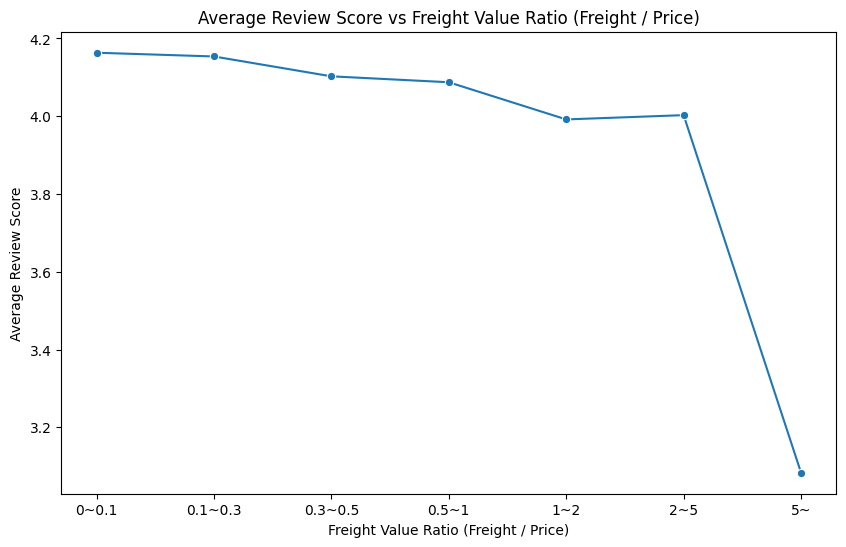

In [71]:
df_order_ratio = df[["order_id", "review_score", "freight_ratio"]].drop_duplicates().copy()

bins = [0, 0.1, 0.3, 0.5, 1, 2, 5, np.inf]
labels = ["0~0.1", "0.1~0.3", "0.3~0.5", "0.5~1", "1~2", "2~5", "5~"]

df_order_ratio["freight_bin"] = pd.cut(
    df_order_ratio["freight_ratio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

ratio_review = df_order_ratio.groupby("freight_bin")["review_score"].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(
    x=ratio_review.index,
    y=ratio_review.values,
    marker="o"
)

plt.title("Average Review Score vs Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio (Freight / Price)")
plt.ylabel("Average Review Score")
plt.show()

freight_bin
0~0.1      15617
0.1~0.3    47095
0.3~0.5    18568
0.5~1      12342
1~2         2818
2~5          354
5~            12
Name: count, dtype: int64

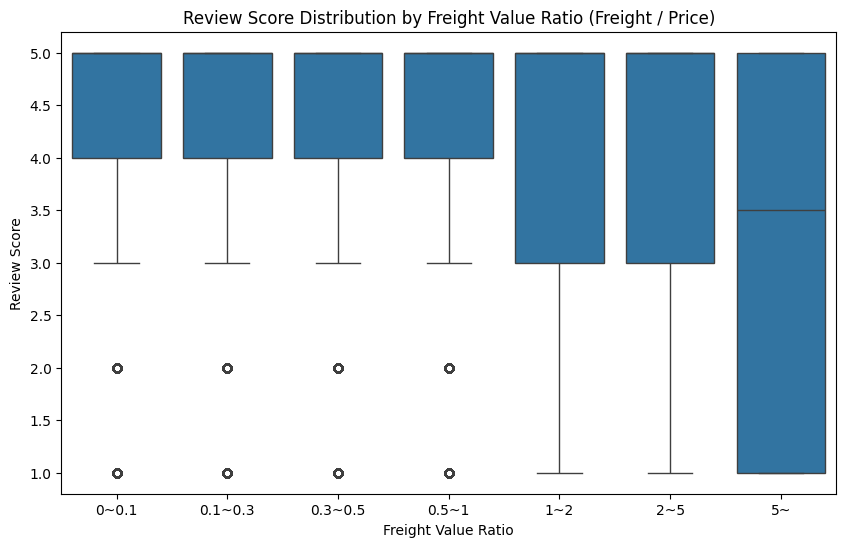

In [76]:
# 주문 단위 freight_ratio + review_score만 남기기
df_order_ratio = df[["order_id", "review_score", "freight_ratio"]].drop_duplicates().copy()

# 배송비 비율 구간 나누기
bins = [0, 0.1, 0.3, 0.5, 1, 2, 5, np.inf]
labels = ["0~0.1", "0.1~0.3", "0.3~0.5", "0.5~1", "1~2", "2~5", "5~"]

df_order_ratio["freight_bin"] = pd.cut(
    df_order_ratio["freight_ratio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 구간별 개수 확인
display(df_order_ratio["freight_bin"].value_counts().sort_index())

# boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_order_ratio,
    x="freight_bin",
    y="review_score"
)

plt.title("Review Score Distribution by Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio")
plt.ylabel("Review Score")

plt.show()

,freight_bin,review_score
0,0~0.1,4.163348
1,0.1~0.3,4.153732
2,0.3~0.5,4.102650
3,0.5~1,4.087425
4,1~2,3.991838
5,2~5,4.002825
6,5~,3.083333


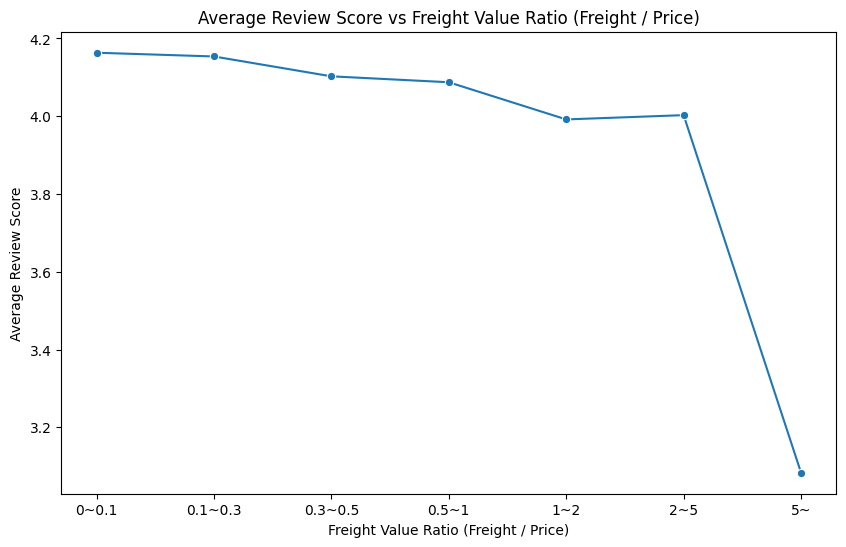

In [75]:
# 구간별 평균 리뷰 계산
ratio_review = (
    df_order_ratio.groupby("freight_bin")["review_score"]
    .mean()
    .reset_index()
)

display(ratio_review)

# line plot
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=ratio_review,
    x="freight_bin",
    y="review_score",
    marker="o"
)

plt.title("Average Review Score vs Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio (Freight / Price)")
plt.ylabel("Average Review Score")

plt.show()

Spearman r: -0.029115975277877647
p-value: 1.2943775883758987e-19


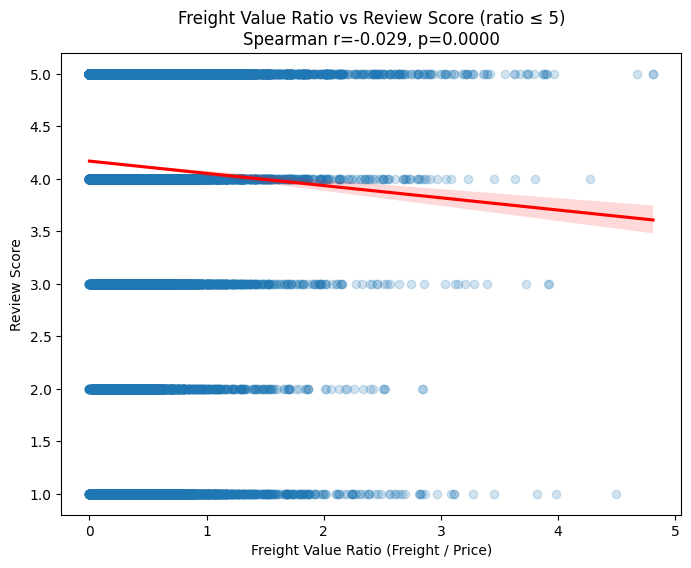

In [77]:
from scipy.stats import spearmanr

r, p = spearmanr(
    df_order_ratio["freight_ratio"],
    df_order_ratio["review_score"]
)

print("Spearman r:", r)
print("p-value:", p)

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_order_ratio[df_order_ratio["freight_ratio"] <= 5],
    x="freight_ratio",
    y="review_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title(f"Freight Value Ratio vs Review Score (ratio ≤ 5)\nSpearman r={r:.3f}, p={p:.4f}")
plt.xlabel("Freight Value Ratio (Freight / Price)")
plt.ylabel("Review Score")

plt.show()

In [68]:
from scipy.stats import spearmanr

r, p = spearmanr(
    df_order["freight_ratio"],
    df_order["review_score"]
)

print("Spearman r:", r)
print("p-value:", p)

Spearman r: -0.03227687469845108
p-value: 4.163512842618433e-23


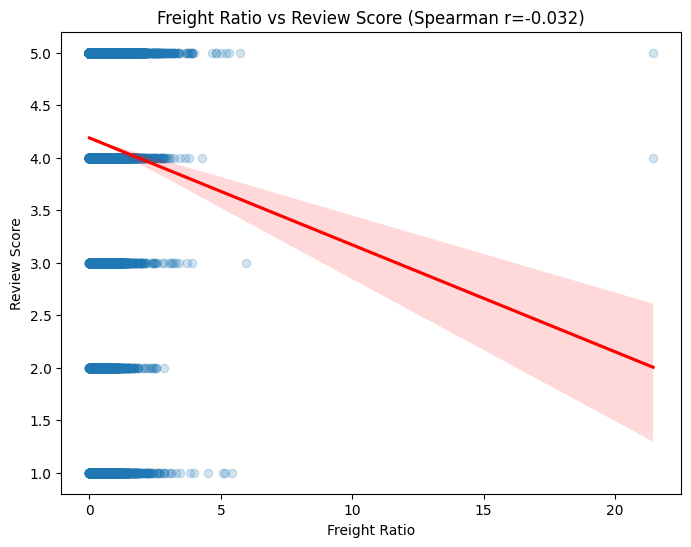

In [69]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_order,
    x="freight_ratio",
    y="review_score",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"Freight Ratio vs Review Score (Spearman r={r:.3f})")
plt.xlabel("Freight Ratio")
plt.ylabel("Review Score")

plt.show()